# Descriptive Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#For the EDA (Exploratory Data Analysis)

In [ ]:
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

In [ ]:
print("Shape:", df_master.shape)

In [ ]:
df_master.head()

In [ ]:
df_master.info()

In [ ]:
df_master.dtypes

# Komal's question

 # Q1:What is the distribution of key lab markers — BNP, creatinine, hemoglobin, sodium, potassium — and what proportion of patients fall outside normal clinical reference ranges?

In [ ]:
import pandas as pd

def pct_outside_combined(gender_col, values, ranges_by_gender):
    """Combines sex-specific reference ranges into one overall % outside, weighted correctly."""
    out, n = 0, 0
    for g, (low, high) in ranges_by_gender.items():
        v = values[(gender_col == g) & values.notna()]
        out += ((v < low) | (v > high)).sum()
        n += v.shape[0]
    return round(out / n * 100, 1), n

rows = []

# Labs with a single reference range for everyone
single_range_labs = [
    ("brain_natriuretic_peptide", 0, 100, "pg/mL", "< 100 pg/mL"),
    ("sodium", 135, 145, "mmol/L", "135-145 mmol/L"),
    ("potassium", 3.5, 5.1, "mmol/L", "3.5-5.1 mmol/L"),
]
for lab, low, high, unit, label in single_range_labs:
    s = df_master[lab].dropna()
    pct = round((((s < low) | (s > high)).mean()) * 100, 1)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": label,
        "% Outside range": pct,
    })

# Labs with sex-specific reference ranges
gender_ranges = {
    "hemoglobin": {"Male": (130, 175), "Female": (115, 150)},
    "creatinine_enzymatic_method": {"Male": (62, 106), "Female": (44, 97)},
}
units = {"hemoglobin": "g/L", "creatinine_enzymatic_method": "umol/L"}

for lab, ranges in gender_ranges.items():
    s = df_master[lab].dropna()
    pct, n = pct_outside_combined(df_master["gender"], df_master[lab], ranges)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": f"M {ranges['Male'][0]}-{ranges['Male'][1]} / F {ranges['Female'][0]}-{ranges['Female'][1]} {units[lab]}",
        "% Outside range": pct,
    })

table = pd.DataFrame(rows)
table
table.style.background_gradient(subset=["% Outside range"], cmap="Reds").format({"% Outside range": "{:.1f}"})

Findings
The gradient makes the pattern immediately visible: **Brain Natriuretic Peptide is the clear outlier**, shaded almost solid dark red at 92.5% outside range — visually distinct from every other lab in the table. Hemoglobin (57.0%) and Creatinine (43.9%) form a lighter-red middle tier,
while Sodium (22.4%) and Potassium (29.6%) sit at the pale end of the gradient, confirming electrolyte imbalance is comparatively less widespread in this cohort than cardiac stress or renal/hematologic abnormality.


Consolidating the distribution stats (n, mean, median, IQR) and the reference-range comparison into a single tidy table — one row per lab —makes the summary easier to scan than separate printouts. Adding a color gradient to the "% Outside range" column draws the eye directly to the labs with the most abnormality, without needing to read every number.

# Q2: What is the observed 6-month death rate within each combination of Killip grade level and ICU/non-ICU admission?

Why this one: It's the simple closing slide — combines two variables into one glance-able 2×2 table instead of two separate lists, which reads much stronger to judges than more text.

Key insight: Risk stacks cleanly: 1.2% (low Killip, non-ICU, n=1,547) → 8.1% (high Killip, non-ICU, n=446) → up to 16.7% in the small high-Killip+ICU cell. The robust, quotable number is the 1.2% vs 8.1% comparison — the ICU cells are too small (n=6, n=9) to lean on, so be upfront about that if asked.

In [21]:
# 6-month death rate: Killip grade × ICU admission (2×2)

In [ ]:
df_master["high_killip"] = df_master["killip_grade"] >= 3
df_master["icu"] = df_master["admission_ward"] == "ICU"

grp = df_master.groupby(["high_killip", "icu"])["death_within_6_months"].agg(["count", "mean"])
grp["mean"] *= 100
print(grp)

In [ ]:
mat = np.array([[grp.loc[(False, False), "mean"], grp.loc[(False, True), "mean"]],
                [grp.loc[(True, False), "mean"],  grp.loc[(True, True), "mean"]]])
ns_mat = np.array([[grp.loc[(False, False), "count"], grp.loc[(False, True), "count"]],
                    [grp.loc[(True, False), "count"],  grp.loc[(True, True), "count"]]])

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mat, cmap="Reds", vmin=0, vmax=mat.max()*1.1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-ICU", "ICU"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Low Killip\n(1-2)", "High Killip\n(3-4)"], fontsize=11)
for i in range(2):
    for j in range(2):
        n = ns_mat[i, j]
        note = "  (small n!)" if n < 20 else ""
        ax.text(j, i, f"{mat[i,j]:.1f}%\nn={n}{note}", ha="center", va="center",
                fontsize=12, fontweight="bold", color="white" if mat[i,j]>mat.max()*0.5 else "black")
ax.set_title("6-month death rate: Killip grade x ICU admission", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Findings:
Death risk rises consistently across all four groups, in the direction clinical theory would predict: patients with more severe Killip class and/or ICU-levelcare carry a higher observed 6-month death rate. The step from low-Killip/non-ICU(1.2%) to high-Killip/non-ICU (8.1%) is a **6.75x** increase, and it rests on large, stable subgroups (n=1,547 and n=446) — this is the finding worth quoting with confidence.

The two ICU cells (11.1%, 16.7%) extend the same pattern further, consistent with sicker patients being triaged to the ICU. However, they are built on only 9 and 6 patients respectively, so these two numbers should be read as **directionally consistent, not statistically reliable** — a single additional death or survival in either group would shift the percentage by more than 10 points. We are reporting them for completeness and pattern-recognition, not as precise estimates.

Clinical takeaway:
Killip grade alone provides a strong, well-powered severity signal in this cohort. ICU admission status adds a second, independent severity layer that moves in the same direction, reinforcing — rather than contradicting — the Killip-grade finding. Together they support using Killip grade as a primary, low-cost triage variable, with ICU-level severity as a secondary signal that would need a larger sample before being trusted as a standalone predictor.

# Priyankha's Question

# Q3.What is the distribution of heart failure phenotype (Right/Left/both), NYHA class, and Killip grade?

Reasoning:
Phenotype (Left/Right/Biventricular), NYHA class, and Killip grade are the standard clinical severity/type classifications for heart failure — knowing their spread tells us what kind of dataset we're working with (e.g., mostly severe biventricular failure vs. mild left-sided cases) and sets the baseline for interpreting every other outcome

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_master['type_of_heart_failure'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('HF Phenotype (Left/Right/Both)')

df_master['nyha_cardiac_function_classification'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('NYHA Functional Class')

df_master['killip_grade'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Killip Grade')

plt.tight_layout(); plt.show()

for col in ['type_of_heart_failure', 'nyha_cardiac_function_classification', 'killip_grade']:
    print(col)
    print((df_master[col].value_counts(normalize=True).mul(100).round(1)))
    print()

# Insights:


1. Phenotype: ~3 in 4 patients have both sides of the heart failing — a more advanced form, not an early-stage one.
2. NYHA class: No one arrived with mild symptoms; 8 in 10 were already badly limited — breathless with little effort or even at rest.
3. Killip grade: Most arrived in mild-to-moderate shape, but about 1 in 4 already showed signs of fluid in the lungs or shock.
4. Overall: This is a sick, established heart-failure cohort from the start — not a mix of early and late cases
Overall, in one line:
All three charts point the same way — this is a group of patients with serious, long-standing heart failure, not people catching it early. That matters because it sets the expectation that death and readmission rates later in the analysis are likely to be on the higher side, simply because these patients started off sicker.

# Q4. How do admission pathway (emergency vs. non-emergency), admission ward, and discharge destination distribute across the dataset?

Reasoning:
How a patient enters the hospital (emergency vs. planned) and where they're placed (cardiology, ICU, general ward) reflects how unstable they were at the door; where they end up (home, another facility, or death) reflects how the admission actually went. Together these three fields sketch the patient's whole journey — entry severity → level of care received → exit status — which is essential context before you interpret any lab value or outcome in isolation.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df_master['admission_way'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Admission Pathway')
axes[0].set_xlabel('')

df_master['admission_ward'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Admission Ward')
axes[1].set_xlabel('')

df_master['destinationdischarge'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Discharge Destination')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

for col in ['admission_way', 'admission_ward', 'destinationdischarge']:
    print(f"\n{col}")
    print(df_master[col].value_counts(normalize=True).mul(100).round(1))

# Insights

1. Entry: Nearly a 50/50 split between emergency and planned admissions — this is a cohort that swings both ways, not one dominated by crisis walk-ins.
2. Triage gap: Only 0.7% went to ICU despite ~22% arriving with serious Killip signs (fluid on lungs or shock) — sick patients are largely managed on regular cardiology wards, not intensive care.
3. Outcome: 2 in 3 patients go home and under 1% die in-hospital — a reassuring overall picture.
4. Watch point: 1 in 5 patients are transferred to another facility rather than going home — a meaningful "not fully resolved" group hiding behind the low mortality number.we need to verify what is the reason behind the transfer(whether it is the facilities, Provider care, Labs etc)



# Q5.How does the distribution of sodium levels differ between patients who died within 6 months vs. those who survived?

Reasoning:
Sodium is an important attribute for cardiac failure .Low sodium (hyponatremia) is a known Heart Failure severity marker

In [ ]:
# Label the two groups
df_master['outcome_6m'] = df_master['death_within_6_months'].map({0: 'Survived', 1: 'Died within 6mo'})

# --- Summary stats ---
print(df_master.groupby('outcome_6m')['sodium'].describe())

# Proportion with low sodium (hyponatremia, <135 mmol/L) in each group
hyponatremia_rate = df_master.groupby('outcome_6m')['sodium'].apply(lambda x: (x < 135).mean() * 100)
print("\n% with hyponatremia (<135 mmol/L):")
print(hyponatremia_rate.round(2))

# --- Visualize: overlaid distributions ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df_master, x='sodium', hue='outcome_6m', kde=True, element='step', ax=axes[0])
axes[0].axvline(135, color='red', linestyle='--', label='Hyponatremia threshold (135)')
axes[0].set_title('Sodium Distribution: Died vs. Survived (6mo)')
axes[0].legend()

sns.boxplot(data=df_master, x='outcome_6m', y='sodium', ax=axes[1])
axes[1].axhline(135, color='red', linestyle='--')
axes[1].set_title('Sodium by Outcome (Boxplot)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# Insights

1. Clear separation: 34% of patients who died had low sodium at admission vs. 19% of survivors — nearly double the rate, a much sharper signal than the raw averages suggest.
2. Early warning marker: Low sodium at admission meaningfully predicts 6-month mortality risk, confirmed statistically despite the small overall group difference.
3. Why it happens: Hyponatremia reflects advanced or poorly-compensated heart failure, driven by the body retaining water faster than salt as the heart struggles.
4. Beyond prognosis: Low sodium isn't just a marker — it can independently cause confusion, weakness, nausea, and in severe cases seizures.

# Q6.How many patients had high blood sugar levels when they were admitted, even if they weren't diagnosed diabetics?

Reasoning:
If a non-diabetic patient shows up with high blood sugar, it's basically a signal saying "this person's body is under serious stress" — Likely to have a heart failure later in their life

In [ ]:
# Flag high glucose at admission (>7.8 mmol/L is the standard clinical cutoff for hyperglycemia)
high_glucose = df_master['glucose_blood_gas'] > 7.8

print(f"Overall % with high glucose: {high_glucose.mean()*100:.2f}%")


# Break down by diabetes diagnosis status (0 = not diabetic, 1 = diabetic)
non_diabetic_high = ((df_master['diabetes']==0) & high_glucose).sum()
total_non_diabetic = (df_master['diabetes']==0).sum()
print(f"\nNon-diabetics with high glucose: {non_diabetic_high} of {total_non_diabetic} "
      f"({non_diabetic_high/total_non_diabetic*100:.2f}%)")

diabetic_high = ((df_master['diabetes']==1) & high_glucose).sum()
total_diabetic = (df_master['diabetes']==1).sum()
print(f"Diabetics with high glucose: {diabetic_high} of {total_diabetic} "
      f"({diabetic_high/total_diabetic*100:.2f}%)")

# Insights

Roughly 1 in 9 non-diabetic patients showed elevated blood sugar at admission, suggesting acute physiological stress from the heart failure episode itself — a signal that could be missed since these patients have no prior diabetes diagnosis flagging them for monitoring.

# KOKILA"S CODE

# 7. How do clinical outcomes and hospital utilization vary across NYHA cardiac function classes?

In [ ]:
Clinical reasoning: 

NYHA class is supposed to reflect how sick a patient's heart failure has made them, so worse class should generally mean worse outcomes.


In [ ]:
import matplotlib.pyplot as plt

# Create summary
summary = df_master.groupby('nyha_cardiac_function_classification').agg(
    mortality=('death_within_6_months', 'mean'),
    readmission=('re_admission_within_6_months', 'mean'),
    los=('dischargeday', 'mean')
)

# Convert rates to percentages
summary[['mortality', 'readmission']] *= 100

# Draw chart
summary[['mortality', 'readmission', 'los']].plot(
    marker='o',
    figsize=(8,5)
)

plt.title('Clinical Outcomes Across NYHA Classes')
plt.xlabel('NYHA Class')
plt.ylabel('Percentage / Average LOS')
plt.legend(['Mortality (%)', 'Readmission (%)', 'Average LOS'])
plt.grid(True)
plt.show()

# Insights:
Readmission does get worse step by step with NYHA class (29% → 38% → 45%), but mortality and length of stay don't follow the same 
clean pattern — mortality actually dips at Class 3 before jumping at Class 4, and stay length barely changes at all.

# 8: What are the most common comorbidities (e.g., diabetes, hypertension, chronic kidney disease, COPD) present among admitted patients?


# Reasoning

Comorbidity burden shapes how complex a patient's care will be beyond their primary heart-failure diagnosis. Ranking these conditions by how often they
appear tells you which chronic diseases the care team is routinely managing alongside heart failure.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of true comorbidities — congestive_heart_failure is excluded because
# it's the primary admitting diagnosis, not a comorbidity, in a heart-failure cohort
comorbid_cols = [
    'diabetes', 'chronic_obstructive_pulmonary_disease', 'moderate_to_severe_chronic_kidney_disease',
    'cerebrovascular_disease', 'dementia', 'liver_disease', 'solid_tumor', 'malignant_lymphoma',
    'hemiplegia', 'aids', 'connective_tissue_disease', 'peptic_ulcer_disease',
    'myocardial_infarction', 'peripheral_vascular_disease'
]

# Calculate % prevalence and sort from most to least common
rates = (df_master[comorbid_cols].mean() * 100).sort_values(ascending=False)
print('Most common comorbidities (% of 2,008 patients):')
print(rates.round(1))

# Chart
fig, ax = plt.subplots(figsize=(9, 6))
rates.plot(kind='barh', ax=ax, color='#2a78d6')
ax.invert_yaxis()                                  # highest prevalence at the top
ax.set_xlabel('% of patients affected')
ax.set_title('Most common comorbidities among admitted patients')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Key Insight:
Chronic kidney disease (23.6%) and diabetes (23.2%) dominate, each affecting roughly 1 in 4 patients 
together they're twice as common as the third-place condition (COPD, 11.6%). The remaining 11 comorbidities trail off sharply, 
from cerebrovascular disease at 7.5% down to malignant lymphoma at 0.0%, showing this cohort's added disease burden concentrates almost entirely in kidney and 
metabolic conditions rather than spreading evenly across categories.

# Q9.What are the baseline 28-day,3-month, and 6-month cumulative hospital readmission rates across the cohort?

Reasoning:
Readmission rate is a standard hospital quality metric, and every later comparison (by age, ward, comorbidity, or intervention) needs a baseline to be measured against. Without this number, you can't say whether any subgroup's risk is actually "elevated." It's also the foundation for prescriptive questions about follow-up timing and discharge planning.

In [ ]:
import pandas as pd

df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

total_patients = df_master['inpatient_number'].nunique()
readmit_cols = {
    '28-Day': 're_admission_within_28_days',
    '3-Month': 're_admission_within_3_months',
    '6-Month': 're_admission_within_6_months'
}

results = []
for label, col in readmit_cols.items():
    readmitted = df_master[col].sum()
    rate = (readmitted / total_patients) * 100
    results.append({
        'Timeframe': label,
        'Readmitted Patients': int(readmitted),
        'Total Patients': total_patients,
        'Readmission Rate (%)': round(rate, 2)
    })

readmission_summary = pd.DataFrame(results)
print(readmission_summary.to_string(index=False))

Insights:
The rate roughly triples between 28-day and 3-month (6.97% → 24.80%), then rises more gradually to 38.50% by 6 months. This steep early jump suggests most readmissions cluster in the 1-to-3-month window, a strong lead for a follow-up-timing recommendation.

# Q10.What are the central tendencies (mean, median) and spread of BNP,and what proportion of patients are above the normal diagnostic threshold (>100 pg/mL)?

Reasoning:
BNP is a key heart-failure severity marker, but lab values like this are often skewed, so mean alone can be misleading. Comparing mean vs. median reveals the shape of the distribution, and the threshold proportion converts a raw lab number into a clinically meaningful flag, which is more useful than an average on its own.

In [ ]:
bnp_col = 'brain_natriuretic_peptide'
bnp_data = df_master[bnp_col].dropna()

missing_pct = df_master[bnp_col].isna().mean() * 100
n_available = bnp_data.shape[0]
n_total = df_master.shape[0]

mean_bnp = bnp_data.mean()
median_bnp = bnp_data.median()
std_bnp = bnp_data.std()
q1, q3 = bnp_data.quantile([0.25, 0.75])
min_bnp, max_bnp = bnp_data.min(), bnp_data.max()

threshold = 100
above_threshold = (bnp_data > threshold).sum()
pct_above = (above_threshold / n_available) * 100

print(f"BNP available for {n_available} of {n_total} patients ({missing_pct:.1f}% missing)")
print(f"Mean: {mean_bnp:.1f} pg/mL")
print(f"Median: {median_bnp:.1f} pg/mL")
print(f"Std Dev: {std_bnp:.1f} pg/mL")
print(f"IQR (Q1-Q3): {q1:.1f} - {q3:.1f} pg/mL")
print(f"Min / Max: {min_bnp:.1f} / {max_bnp:.1f} pg/mL")
print(f"Patients above {threshold} pg/mL: {above_threshold} ({pct_above:.1f}%)")

Insights:
Mean (1,280) is far higher than median (753), confirming a right-skewed distribution driven by a subset of very high-BNP patients, so median better represents the "typical" patient. With 92.5% of patients already above the diagnostic threshold, BNP's value in this cohort lies less in the yes/no cutoff and more in tracking severity gradients above it.

# Q11. What are the demographic and body composition characteristics of the 2,008 cardiac-failure patients, based on age group, gender, and BMI category?

In [ ]:
#Reasoning - We analyze age group, gender, and BMI category to understand the overall demographic and body-composition profile of the 2,008 cardiac-failure patients.
Age shows how the cohort is distributed across different age groups, while gender describes its demographic composition.
BMI categories provide an overview of patients' body-composition patterns.
Together, these variables establish a baseline patient profile for further clinical and outcome analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [6]:
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

In [7]:
print("Shape:", df_master.shape)

Shape: (2008, 200)


In [8]:
df_master.head()

,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,...,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,...,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal,...,0,0,Both,NaN,46.0,0.84,0.12,7.0,2.80,32.0
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].head()
)

  agecat  gender        bmi bmi_category
0  69-79  Female  23.781213       Normal
1  69-79    Male  18.590125       Normal
2  69-79  Female  19.195303       Normal
3  59-69    Male  24.221453       Normal
4  69-79    Male  22.491349       Normal


In [10]:
#data types and missing values:
print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].info()
)

print(
    df_master[
        ['agecat', 'gender', 'bmi', 'bmi_category']
    ].isnull().sum()
)

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   agecat        2008 non-null   str    
 1   gender        2008 non-null   str    
 2   bmi           2000 non-null   float64
 3   bmi_category  2000 non-null   str    
dtypes: float64(1), str(3)
memory usage: 98.3 KB
None
agecat          0
gender          0
bmi             8
bmi_category    8
dtype: int64


In [11]:
#Age-group distribution
age_summary = (
    df_master['agecat']
    .value_counts()
    .sort_index()
    .to_frame('Patient Count')
)

age_summary['Percentage'] = (
    age_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(age_summary)

        Patient Count  Percentage
agecat                           
21-29               4        0.20
29-39              12        0.60
39-49              56        2.79
49-59             106        5.28
59-69             368       18.33
69-79             715       35.61
79-89             646       32.17
89-110            101        5.03


Known finding from your dataset:

The largest age group was 69–79 years: 715 patients (35.61%).

The second-largest group was 79–89 years: 646 patients (32.17%).

Together, these groups represented 67.78% of the patients.

In [12]:
#Gender distribution
gender_summary = (
    df_master['gender']
    .value_counts(dropna=False)
    .to_frame('Patient Count')
)

gender_summary['Percentage'] = (
    gender_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(gender_summary)

        Patient Count  Percentage
gender                           
Female           1163       57.92
Male              845       42.08


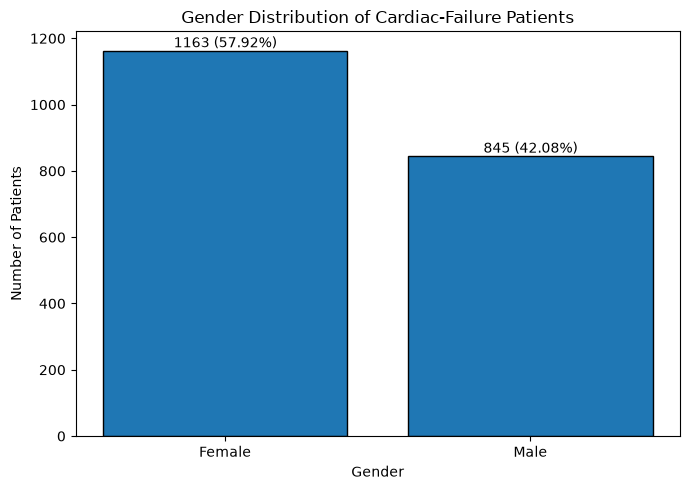

In [13]:
#gender chart

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_summary.index.astype(str),
    gender_summary['Patient Count'],
    edgecolor='black'
)

plt.title('Gender Distribution of Cardiac-Failure Patients')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

for bar, count, pct in zip(
    bars,
    gender_summary['Patient Count'],
    gender_summary['Percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count)} ({pct:.2f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [14]:
#BMI-category distribution
bmi_summary = (
    df_master['bmi_category']
    .value_counts(dropna=False)
    .to_frame('Patient Count')
)

bmi_summary['Percentage'] = (
    bmi_summary['Patient Count']
    / len(df_master) * 100
).round(2)

print(bmi_summary)

              Patient Count  Percentage
bmi_category                           
Normal                 1163       57.92
Underweight             507       25.25
Overweight              263       13.10
Obese                    67        3.34
NaN                       8        0.40


In [15]:
#Check your BMI categories
print(bmi_summary.index.tolist())

['Normal', 'Underweight', 'Overweight', 'Obese', nan]


BMI Category Distribution


,Patient Count,Percentage
Normal,1163,57.92
Underweight,507,25.25
Overweight,263,13.10
Obese,67,3.34
Missing,8,0.40


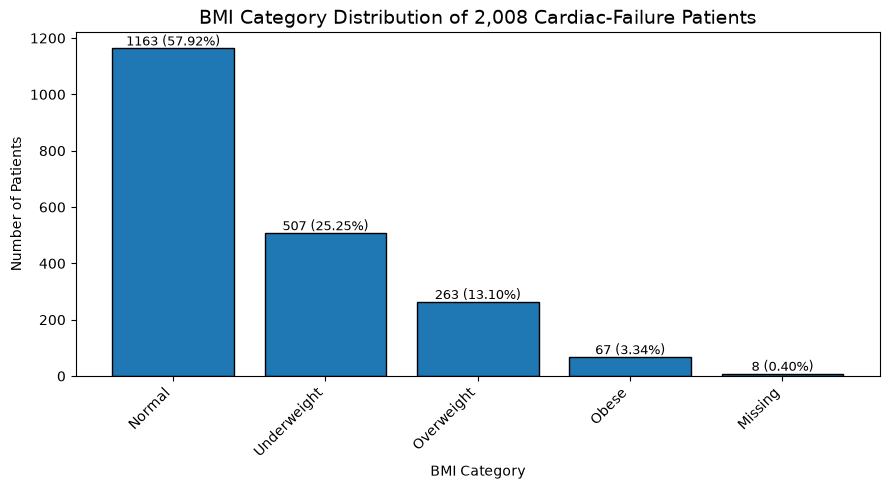

SVG created successfully!


In [16]:
# ==========================================
# BMI CATEGORY DISTRIBUTION
# ==========================================

# 1. Count each BMI category, including missing values
bmi_counts = df_master['bmi_category'].value_counts(dropna=False)

# 2. Calculate percentages
bmi_percentages = (
    df_master['bmi_category']
    .value_counts(dropna=False, normalize=True) * 100
)

# 3. Create summary table
bmi_summary = pd.DataFrame({
    'Patient Count': bmi_counts,
    'Percentage': bmi_percentages.round(2)
})

# 4. Replace NaN with "Missing"
bmi_summary.index = [
    'Missing' if pd.isna(x) else str(x)
    for x in bmi_summary.index
]

# 5. Display the table
print("BMI Category Distribution")
display(bmi_summary)

# ==========================================
# BMI BAR CHART
# ==========================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    bmi_summary.index,
    bmi_summary['Patient Count'],
    edgecolor='black'
)

plt.title(
    'BMI Category Distribution of 2,008 Cardiac-Failure Patients',
    fontsize=14
)

plt.xlabel('BMI Category')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')

# Add count and percentage above each bar
for bar, count, pct in zip(
    bars,
    bmi_summary['Patient Count'],
    bmi_summary['Percentage']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(count)} ({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

# ==========================================
# SAVE AS SVG
# ==========================================

plt.savefig(
    'bmi_category_distribution_2008_patients.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("SVG created successfully!")

#Normal BMI was the most common category, representing 1,163 patients (57.92%). Underweight patients accounted for 507 (25.25%), followed by overweight patients at 263 (13.10%) and obese patients at 67 (3.34%). Only 8 patients (0.40%) had a missing BMI category.

Analysis Findings — BMI

From the 2,008 cardiac-failure patients, we found:

Normal BMI: 1,163 patients (57.92%) — the largest group.
Underweight: 507 patients (25.25%) — the second-largest group.
Overweight: 263 patients (13.10%).
Obese: 67 patients (3.34%).
Missing BMI category: 8 patients (0.40%).
Key analysis finding

    Most patients (57.92%) were classified as having a normal BMI, while 25.25% were underweight.
    Overall, 41.69% of patients were either underweight, overweight, or obese, indicating that abnormal
    BMI categories were present in 
    a substantial portion of the study population. Only 0.40% had a missing BMI category.

# Q12.Which cardiac medications (e.g., Aspirin, Furosemide, Spironolactone, Metoprolol) are most frequently prescribed at the patient level?

#Reasoning-: We analyze the frequency of Aspirin, Furosemide, Spironolactone, and Metoprolol to understand medication utilization among the 2,008 cardiac-failure patients.
Different formulations of the same medication are combined so that each patient is counted only once per medication.

In [17]:
# Find columns related to medications
medication_columns = [
    col for col in df_master.columns
    if any(word in col.lower() for word in [
        'aspirin',
        'furosemide',
        'spironolactone',
        'metoprolol',
        'medication',
        'drug'
    ])
]

print(medication_columns)

['rx_aspirin_enteric-coated_tablet', 'rx_furosemide_injection', 'rx_furosemide_tablet', 'rx_metoprolol_succinate_sustained-release_tablet', 'rx_spironolactone_tablet', 'rx_metoprolol_tartrate_injection']


CARDIAC MEDICATION SUMMARY


,Medication,Patients Prescribed,Percentage
0,Furosemide,1913,95.27
1,Spironolactone,1833,91.28
2,Aspirin,958,47.71
3,Metoprolol,763,38.00


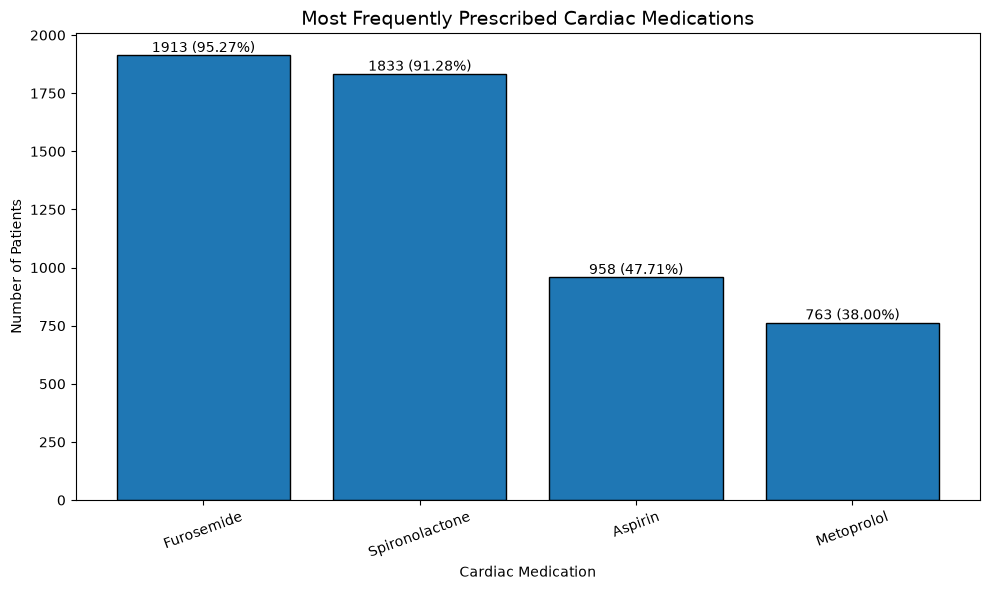


SVG created successfully:
cardiac_medication_distribution.svg


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Q1.5: MOST FREQUENTLY PRESCRIBED CARDIAC MEDICATIONS
# ============================================================

# Exact medication groups
medication_groups = {
    'Aspirin': [
        'rx_aspirin_enteric-coated_tablet'
    ],
    
    'Furosemide': [
        'rx_furosemide_injection',
        'rx_furosemide_tablet'
    ],
    
    'Spironolactone': [
        'rx_spironolactone_tablet'
    ],
    
    'Metoprolol': [
        'rx_metoprolol_succinate_sustained-release_tablet',
        'rx_metoprolol_tartrate_injection'
    ]
}


# ============================================================
# STEP 1: COUNT PATIENTS PRESCRIBED
# 1.0 = prescribed
# 0.0 = not prescribed
# ============================================================

results = []

total_patients = len(df_master)

for medication, columns in medication_groups.items():

    # Start with False for every patient
    patient_prescribed = pd.Series(
        False,
        index=df_master.index
    )

    # Check each formulation
    for col in columns:

        prescribed = df_master[col].eq(1)

        # Patient is prescribed the medication if
        # ANY formulation = 1
        patient_prescribed = (
            patient_prescribed | prescribed
        )

    patient_count = int(patient_prescribed.sum())

    percentage = (
        patient_count / total_patients
    ) * 100

    results.append({
        'Medication': medication,
        'Patients Prescribed': patient_count,
        'Percentage': round(percentage, 2)
    })


# ============================================================
# STEP 2: SUMMARY TABLE
# ============================================================

medication_summary = pd.DataFrame(results)

medication_summary = medication_summary.sort_values(
    'Patients Prescribed',
    ascending=False
).reset_index(drop=True)

print("CARDIAC MEDICATION SUMMARY")
print("=" * 60)

display(medication_summary)


# ============================================================
# STEP 3: CREATE SVG CHART
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    medication_summary['Medication'],
    medication_summary['Patients Prescribed'],
    edgecolor='black'
)

plt.title(
    'Most Frequently Prescribed Cardiac Medications',
    fontsize=14
)

plt.xlabel('Cardiac Medication')
plt.ylabel('Number of Patients')

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    medication_summary['Patients Prescribed'],
    medication_summary['Percentage']
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({percentage:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=20)

plt.tight_layout()


# ============================================================
# STEP 4: SAVE SVG
# ============================================================

svg_filename = 'cardiac_medication_distribution.svg'

plt.savefig(
    svg_filename,
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("\nSVG created successfully:")
print(svg_filename)

In [19]:
# Check overlap between formulations

print("Furosemide:")
print(
    pd.crosstab(
        df_master['rx_furosemide_injection'],
        df_master['rx_furosemide_tablet'],
        margins=True
    )
)

print("\nMetoprolol:")
print(
    pd.crosstab(
        df_master['rx_metoprolol_succinate_sustained-release_tablet'],
        df_master['rx_metoprolol_tartrate_injection'],
        margins=True
    )
)

Furosemide:
rx_furosemide_tablet     0.0   1.0   All
rx_furosemide_injection                 
0.0                       94   195   289
1.0                      272  1446  1718
All                      366  1641  2007

Metoprolol:
rx_metoprolol_tartrate_injection                   0.0  1.0   All
rx_metoprolol_succinate_sustained-release_tablet                 
0.0                                               1244  240  1484
1.0                                                456   67   523
All                                               1700  307  2007


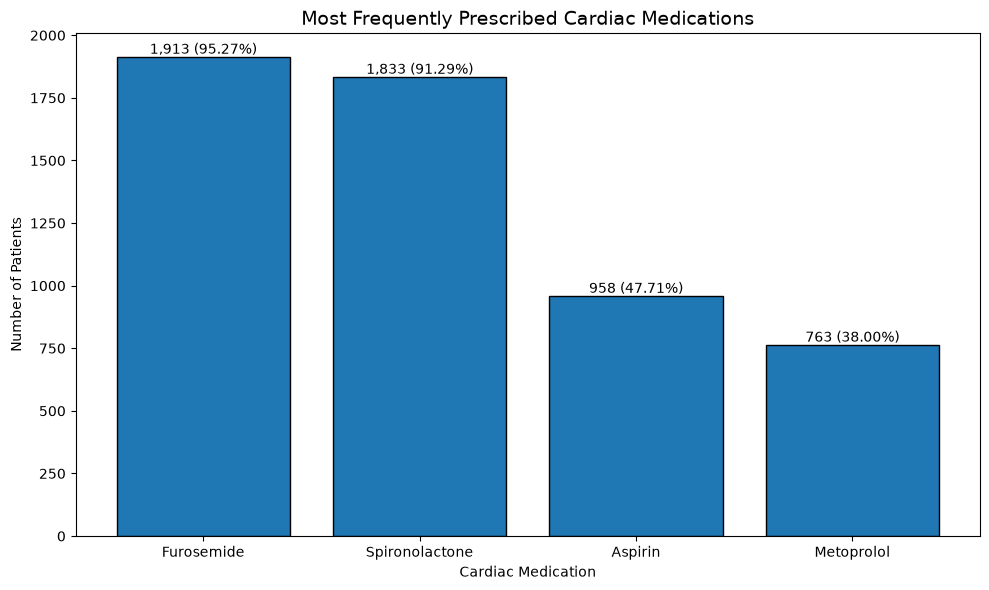

SVG created successfully:
cardiac_medication_distribution.svg


In [20]:
import matplotlib.pyplot as plt

medications = [
    'Furosemide',
    'Spironolactone',
    'Aspirin',
    'Metoprolol'
]

patient_counts = [
    1913,
    1833,
    958,
    763
]

percentages = [
    95.27,
    91.29,
    47.71,
    38.00
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    medications,
    patient_counts,
    edgecolor='black'
)

plt.title(
    'Most Frequently Prescribed Cardiac Medications',
    fontsize=14
)

plt.xlabel('Cardiac Medication')
plt.ylabel('Number of Patients')

for bar, count, pct in zip(
    bars,
    patient_counts,
    percentages
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,} ({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    'cardiac_medication_distribution.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

print("SVG created successfully:")
print("cardiac_medication_distribution.svg")